# Experiment: MediaPipe Export and Features

What this notebook teaches:
- Run frame-by-frame MediaPipe inference on a short clip.
- Export canonical keypoints to CSV/JSON for downstream analysis.
- Compute joint angles, smoothed curves, and angular velocities.
- Save compact benchmark and feature artifacts.


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sumeyye-agac/human-pose-estimation-experiments.git"
REPO_NAME = "human-pose-estimation-experiments"
COLAB_REPO_DIR = Path("/content") / REPO_NAME

if "google.colab" in sys.modules:
    if not COLAB_REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    os.chdir(COLAB_REPO_DIR)

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not locate repository root containing src/.")

os.chdir(repo_root)
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

print(f"Using repo root: {repo_root}")


Using repo root: /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments


In [2]:
def pip_install(*packages: str) -> None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade-strategy", "only-if-needed", *packages], check=True)

pip_install(
    "numpy<2",
    "pandas>=2.1,<2.3",
    "matplotlib>=3.8,<3.9",
    "scipy>=1.11,<1.12",
    "opencv-python-headless<5",
    "mediapipe==0.10.14",
)


I0000 00:00:1772742630.789841 12593521 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772742630.849243 12593639 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772742630.853852 12593639 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/.venv-nb/lib/python3.11/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


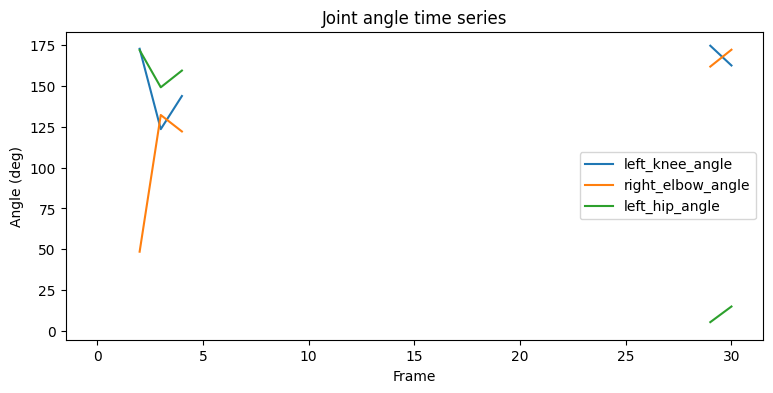

Saved:
- /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/results/mediapipe_sequence_canonical.csv
- /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/results/mediapipe_sequence_canonical.json
- /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/results/mediapipe_features_summary.json


In [3]:
import json
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd

from posebench.benchmark import BenchmarkConfig, benchmark_backend, write_json
from posebench.export import export_frames_to_csv, export_frames_to_json
from posebench.features import compute_angular_velocity, extract_joint_angles, smooth_series, summarize_series_features
from posebench.keypoints_schema import map_tool_keypoints_to_canonical


def download_file(url: str, destination: Path) -> None:
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=25) as response, destination.open("wb") as f:
        f.write(response.read())


def generate_synthetic_video(path: Path, width: int = 640, height: int = 360, fps: int = 24, frames: int = 64) -> None:
    writer = cv2.VideoWriter(str(path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))
    for i in range(frames):
        canvas = np.full((height, width, 3), 245, dtype=np.uint8)
        x = int(100 + (width - 200) * (i / max(frames - 1, 1)))
        y = int(height / 2 + 40 * np.sin(i / 5))
        cv2.circle(canvas, (x, y), 30, (40, 40, 40), 3)
        cv2.line(canvas, (x, y + 30), (x, y + 110), (40, 40, 40), 3)
        cv2.line(canvas, (x, y + 55), (x - 45, y + 80), (40, 40, 40), 3)
        cv2.line(canvas, (x, y + 55), (x + 45, y + 80), (40, 40, 40), 3)
        cv2.line(canvas, (x, y + 110), (x - 30, y + 170), (40, 40, 40), 3)
        cv2.line(canvas, (x, y + 110), (x + 30, y + 170), (40, 40, 40), 3)
        writer.write(canvas)
    writer.release()


def ensure_sample_video(path: Path) -> Path:
    if path.exists():
        return path

    urls = [
        "https://raw.githubusercontent.com/opencv/opencv_extra/master/testdata/cv/tracking/faceocc2.webm",
        "https://samplelib.com/lib/preview/mp4/sample-5s.mp4",
    ]
    last_error = None
    for url in urls:
        try:
            download_file(url, path)
            return path
        except Exception as exc:
            last_error = exc

    generate_synthetic_video(path)
    print(f"Sample video download failed ({last_error}); synthetic fallback generated.")
    return path


video_path = repo_root / "assets" / "sample_input_motion.mp4"
video_path.parent.mkdir(parents=True, exist_ok=True)
ensure_sample_video(video_path)

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise RuntimeError("Could not open sample video")

pose = mp.solutions.pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

frames = []
frame_index = 0
max_frames = 48
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

while frame_index < max_frames:
    ok, bgr = cap.read()
    if not ok:
        break

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    result = pose.process(rgb)
    h, w = bgr.shape[:2]

    if result.pose_landmarks:
        points = [
            {"x": lm.x * w, "y": lm.y * h, "confidence": lm.visibility}
            for lm in result.pose_landmarks.landmark
        ]
    else:
        points = []

    canonical = map_tool_keypoints_to_canonical("mediapipe", points, min_confidence=0.1)
    frames.append(
        {
            "frame_index": frame_index,
            "timestamp_ms": (frame_index / fps) * 1000.0,
            "person_id": 0,
            "tool": "mediapipe",
            "schema": "coco17",
            "keypoints": canonical,
        }
    )
    frame_index += 1

cap.release()

csv_path = repo_root / "results" / "mediapipe_sequence_canonical.csv"
json_path = repo_root / "results" / "mediapipe_sequence_canonical.json"
export_frames_to_csv(frames, csv_path)
export_frames_to_json(frames, json_path)

joint_triplets = {
    "left_knee_angle": ("left_hip", "left_knee", "left_ankle"),
    "right_elbow_angle": ("right_shoulder", "right_elbow", "right_wrist"),
    "left_hip_angle": ("left_shoulder", "left_hip", "left_knee"),
}
angles_df = extract_joint_angles(frames, joint_triplets, min_confidence=0.2)
angles_df["left_knee_angle_smooth"] = smooth_series(angles_df["left_knee_angle"], method="savgol")
angles_df["left_knee_velocity"] = compute_angular_velocity(angles_df["left_knee_angle_smooth"], fps=fps)

summary = {
    column: summarize_series_features(angles_df[column].to_numpy())
    for column in ["left_knee_angle", "right_elbow_angle", "left_hip_angle"]
}
summary_path = repo_root / "results" / "mediapipe_features_summary.json"
summary_path.write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")

plt.figure(figsize=(9, 4))
for column in ["left_knee_angle", "right_elbow_angle", "left_hip_angle"]:
    plt.plot(angles_df["frame_index"], angles_df[column], label=column)
plt.xlabel("Frame")
plt.ylabel("Angle (deg)")
plt.title("Joint angle time series")
plt.legend()
plt.show()

class MPBackend:
    name = "mediapipe"

    def __init__(self, pose_model):
        self.pose_model = pose_model

    def infer(self, frame: np.ndarray):
        return self.pose_model.process(frame)

bench_frame = np.random.default_rng(17).integers(0, 255, size=(480, 640, 3), dtype=np.uint8)
bench_result = benchmark_backend(
    backend=MPBackend(pose),
    frames=[bench_frame],
    config=BenchmarkConfig(warmup_frames=8, measured_frames=40, repeat=1),
)
write_json(bench_result, repo_root / "results" / "benchmark_raw_mediapipe_sequence.json")

print("Saved:")
print("-", csv_path)
print("-", json_path)
print("-", summary_path)
